# EN3160 Assignment 01

## Student Details

- **Name:** KPCP Keerawella
- **Index Number:** 230332B
- **GitHub Profile:** chalee88

This notebook contains the final selected solutions only, prepared for PDF submission.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## Helper Functions

In [2]:
def intensity_transform(im, breakpoints):
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]
    input_levels = np.arange(256)
    transform = np.interp(input_levels, x, y)
    transform = np.clip(transform, 0, 255).astype(np.uint8)
    transformed = cv.LUT(im, transform)
    return transformed, transform


def histogram_equalization(im):
    L = 256
    hist = np.zeros(L, dtype=np.int64)
    for pixel in im.ravel():
        hist[pixel] += 1

    cdf = np.cumsum(hist)
    transform = np.round(((L - 1) / im.size) * cdf).astype(np.uint8)
    equalized = transform[im]
    return equalized, hist, transform


def zoom_image(img, scale, method="nearest"):
    if scale <= 0 or scale > 10:
        raise ValueError("Scale must be in the range (0, 10].")

    h, w = img.shape[:2]
    new_h, new_w = int(round(h * scale)), int(round(w * scale))
    out_shape = (new_h, new_w) if img.ndim == 2 else (new_h, new_w, img.shape[2])
    out = np.zeros(out_shape, dtype=np.uint8)

    for y_new in range(new_h):
        for x_new in range(new_w):
            y_src = y_new / scale
            x_src = x_new / scale

            if method == "nearest":
                y = min(int(round(y_src)), h - 1)
                x = min(int(round(x_src)), w - 1)
                out[y_new, x_new] = img[y, x]

            elif method == "bilinear":
                y0 = int(np.floor(y_src))
                x0 = int(np.floor(x_src))
                y1 = min(y0 + 1, h - 1)
                x1 = min(x0 + 1, w - 1)
                y0 = min(y0, h - 1)
                x0 = min(x0, w - 1)

                dy = y_src - y0
                dx = x_src - x0

                top = (1 - dx) * img[y0, x0] + dx * img[y0, x1]
                bottom = (1 - dx) * img[y1, x0] + dx * img[y1, x1]
                value = (1 - dy) * top + dy * bottom
                out[y_new, x_new] = np.clip(value, 0, 255)

            else:
                raise ValueError("method must be 'nearest' or 'bilinear'.")

    return out


def normalized_ssd(reference, test):
    reference = reference.astype(np.float64)
    test = test.astype(np.float64)
    return np.sum((reference - test) ** 2) / reference.size


def convolution2d(im, kernel):
    h, w = im.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(im, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")
    output = np.zeros((h, w), dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i + kh, j:j + kw]
            output[i, j] = np.sum(region * kernel)

    return output


def mse(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    return np.mean((img1 - img2) ** 2)

## Question 01 - Piecewise Linear Intensity Transformation

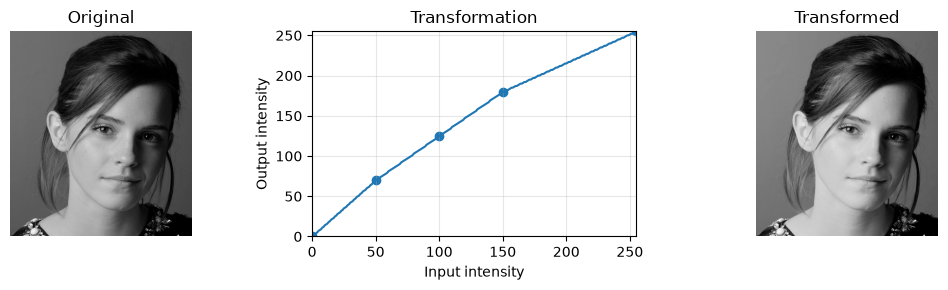

In [3]:
im = cv.imread("images/q1.jpeg", cv.IMREAD_GRAYSCALE)

breakpoints = np.array([
    [0, 0],
    [50, 70],
    [100, 125],
    [150, 180],
    [255, 255]
], dtype=np.float32)

im_transformed, transform = intensity_transform(im, breakpoints)

plt.figure(figsize=(11, 3))
plt.subplot(1, 3, 1)
plt.imshow(im, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.plot(np.arange(256), transform)
plt.scatter(breakpoints[:, 0], breakpoints[:, 1])
plt.title("Transformation")
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.imshow(im_transformed, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed")
plt.axis("off")

plt.tight_layout()
plt.show()

The selected breakpoints moderately expand the shadow and midtone ranges while avoiding the highlight saturation produced by the initial steeper mapping. This improves darker detail while preserving bright-region information.

## Question 02 - Brain Proton Density Image Enhancement

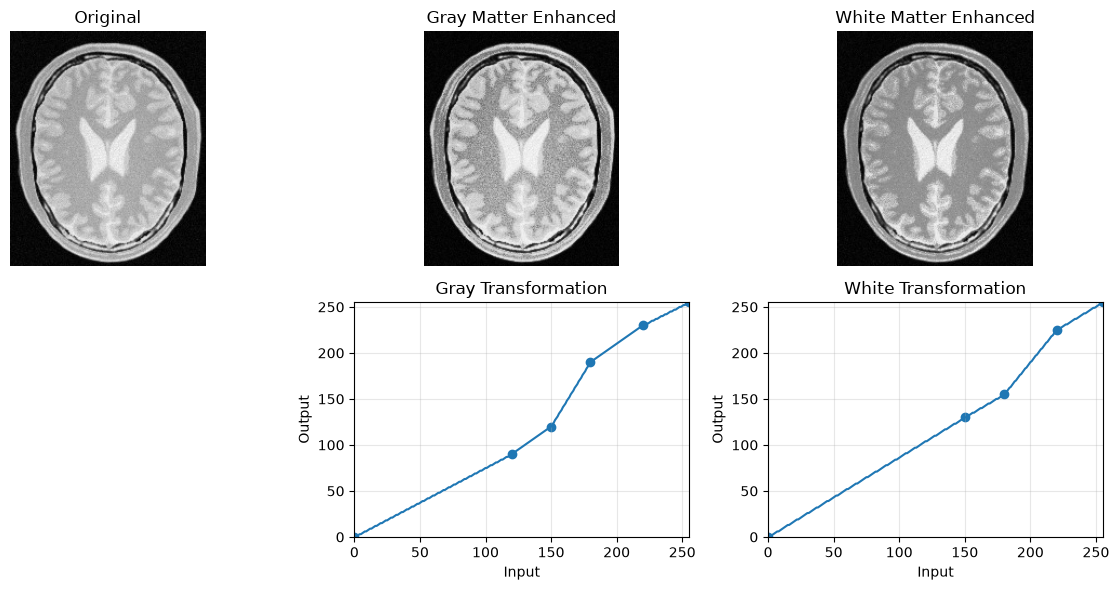

In [4]:
brain = cv.imread("images/q2.jpeg", cv.IMREAD_GRAYSCALE)

gray_breakpoints = np.array([
    [0, 0],
    [120, 90],
    [150, 120],
    [180, 190],
    [220, 230],
    [255, 255]
], dtype=np.float32)

white_breakpoints = np.array([
    [0, 0],
    [150, 130],
    [180, 155],
    [220, 225],
    [255, 255]
], dtype=np.float32)

gray_enhanced, gray_transform = intensity_transform(brain, gray_breakpoints)
white_enhanced, white_transform = intensity_transform(brain, white_breakpoints)

plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1)
plt.imshow(brain, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray_enhanced, cmap="gray", vmin=0, vmax=255)
plt.title("Gray Matter Enhanced")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(white_enhanced, cmap="gray", vmin=0, vmax=255)
plt.title("White Matter Enhanced")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.plot(np.arange(256), gray_transform)
plt.scatter(gray_breakpoints[:, 0], gray_breakpoints[:, 1])
plt.title("Gray Transformation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid(alpha=0.3)

plt.subplot(2, 3, 6)
plt.plot(np.arange(256), white_transform)
plt.scatter(white_breakpoints[:, 0], white_breakpoints[:, 1])
plt.title("White Transformation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The histogram and sampled tissue intensities indicated approximate ranges of 150-180 for gray matter and 180-220 for white matter. Separate piecewise-linear mappings with steeper slopes over those ranges improve contrast for the selected tissues. Since the operation is intensity based, it enhances matching intensity ranges rather than anatomical regions directly.

## Question 03 - Gamma Correction in L*a*b* Color Space

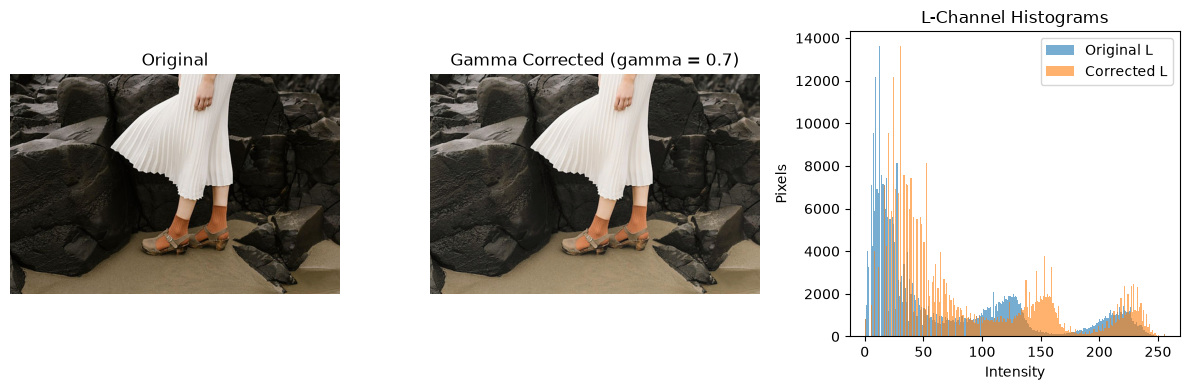

In [5]:
img = cv.imread("images/q3.jpeg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
L, a_channel, b_channel = cv.split(lab)

gamma = 0.7
L_corrected = np.clip((L / 255.0) ** gamma * 255, 0, 255).astype(np.uint8)
lab_corrected = cv.merge([L_corrected, a_channel, b_channel])
corrected_rgb = cv.cvtColor(cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR), cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(corrected_rgb)
plt.title(f"Gamma Corrected (gamma = {gamma})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.hist(L.ravel(), bins=256, range=[0, 256], alpha=0.6, label="Original L")
plt.hist(L_corrected.ravel(), bins=256, range=[0, 256], alpha=0.6, label="Corrected L")
plt.title("L-Channel Histograms")
plt.xlabel("Intensity")
plt.ylabel("Pixels")
plt.legend()

plt.tight_layout()
plt.show()

Gamma correction was applied only to the L channel using gamma = 0.7. Since gamma < 1, lower and mid-range lightness values increased, revealing darker detail while preserving the color channels.

## Question 04 - Vibrance Enhancement Using Saturation Transformation

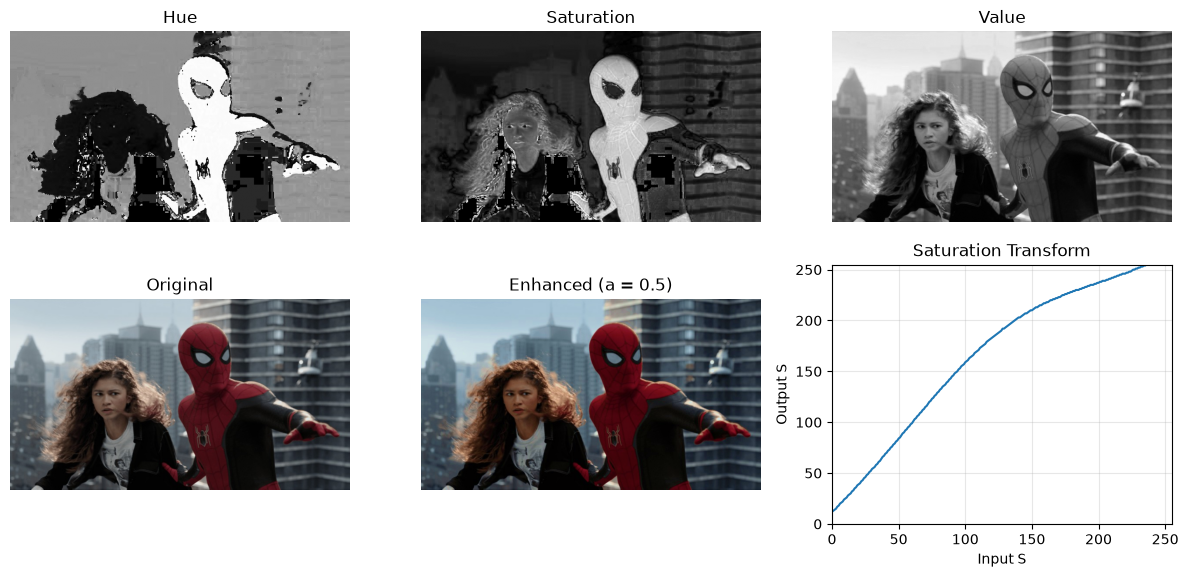

In [6]:
img = cv.imread("images/q4.jpeg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

a = 0.5
sigma = 70
x = np.arange(256, dtype=np.float32)
sat_transform = x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
sat_transform = np.minimum(sat_transform, 255).astype(np.uint8)

S_enhanced = cv.LUT(S, sat_transform)
enhanced_rgb = cv.cvtColor(cv.cvtColor(cv.merge([H, S_enhanced, V]), cv.COLOR_HSV2BGR), cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
for i, (plane, title) in enumerate([(H, "Hue"), (S, "Saturation"), (V, "Value")], start=1):
    plt.subplot(2, 3, i)
    plt.imshow(plane, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(enhanced_rgb)
plt.title(f"Enhanced (a = {a})")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.plot(x, sat_transform)
plt.title("Saturation Transform")
plt.xlabel("Input S")
plt.ylabel("Output S")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The transformation was applied only to the saturation plane in HSV. The selected value a = 0.5 increases moderately saturated colors while keeping hue and value unchanged, so the result appears more vivid without an unnatural brightness shift.

## Question 05 - Histogram Equalization From Scratch

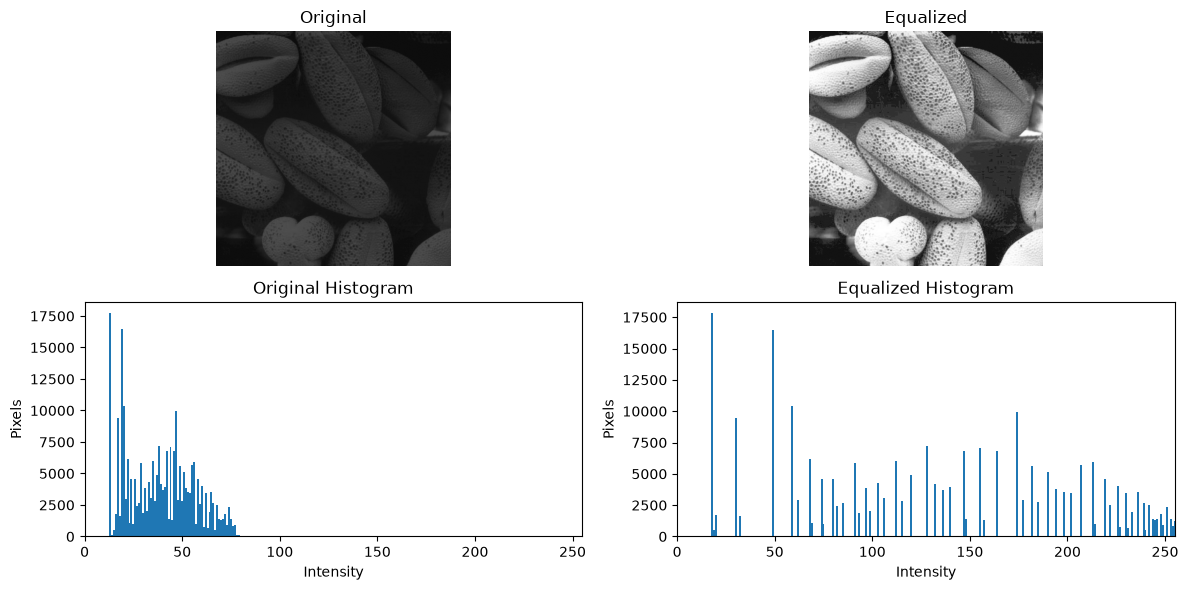

In [7]:
img = cv.imread("images/q5.tif", cv.IMREAD_GRAYSCALE)
equalized, hist_original, he_transform = histogram_equalization(img)

hist_equalized = np.zeros(256, dtype=np.int64)
for pixel in equalized.ravel():
    hist_equalized[pixel] += 1

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(equalized, cmap="gray", vmin=0, vmax=255)
plt.title("Equalized")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.bar(np.arange(256), hist_original, width=1)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixels")
plt.xlim([0, 255])

plt.subplot(2, 2, 4)
plt.bar(np.arange(256), hist_equalized, width=1)
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixels")
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

The equalization mapping was obtained from the cumulative distribution of the original histogram. The output intensities occupy a wider dynamic range, increasing contrast and revealing details in the darker image.

## Question 06 - Foreground-Only Histogram Equalization

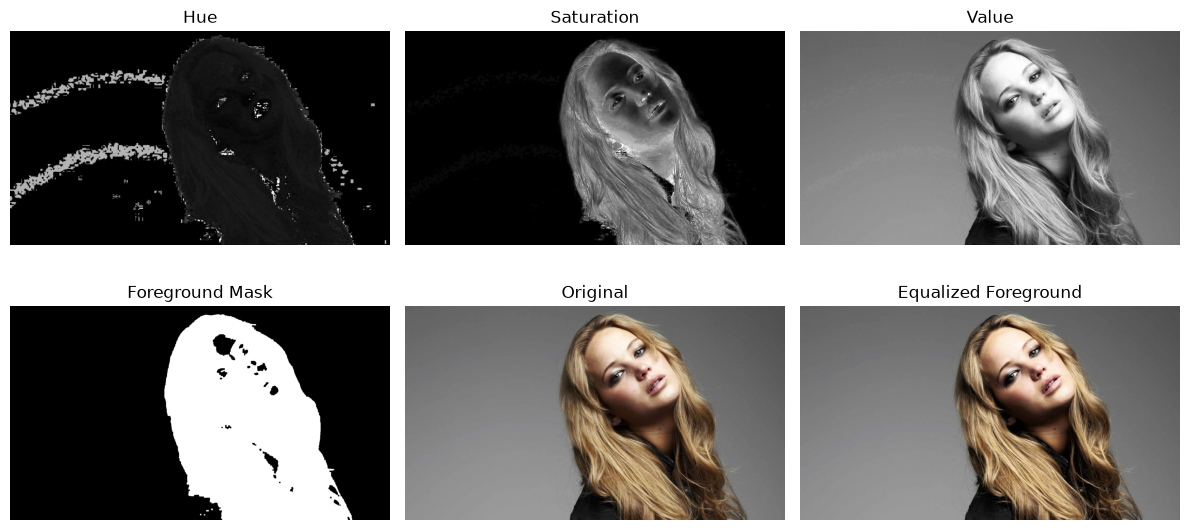

In [8]:
img = cv.imread("images/q6.jpeg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

_, mask = cv.threshold(S, 30, 255, cv.THRESH_BINARY)
kernel = np.ones((5, 5), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)

foreground_values = V[mask == 255]
hist = np.zeros(256, dtype=np.int64)
for pixel in foreground_values:
    hist[pixel] += 1

cdf = np.cumsum(hist)
fg_transform = np.round((255 / foreground_values.size) * cdf).astype(np.uint8)

V_equalized = V.copy()
V_equalized[mask == 255] = fg_transform[V[mask == 255]]
result_rgb = cv.cvtColor(cv.cvtColor(cv.merge([H, S, V_equalized]), cv.COLOR_HSV2BGR), cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
for i, (plane, title) in enumerate([(H, "Hue"), (S, "Saturation"), (V, "Value")], start=1):
    plt.subplot(2, 3, i)
    plt.imshow(plane, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(result_rgb)
plt.title("Equalized Foreground")
plt.axis("off")

plt.tight_layout()
plt.show()

The saturation channel was thresholded to obtain the foreground mask. Histogram equalization was then applied only to foreground pixels in the V channel, while background pixels were left unchanged.

## Question 07 - Sobel Filtering

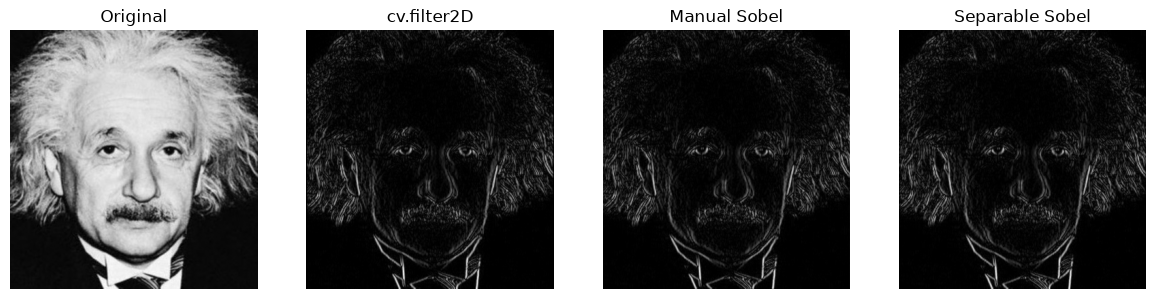

In [9]:
img = cv.imread("images/q7.jpeg", cv.IMREAD_GRAYSCALE)

sobel_x = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

sobel_cv = cv.filter2D(img, cv.CV_32F, sobel_x)
sobel_manual = convolution2d(img.astype(np.float32), sobel_x)

vertical = np.array([[1], [2], [1]], dtype=np.float32)
horizontal = np.array([[1, 0, -1]], dtype=np.float32)
temp = cv.filter2D(img.astype(np.float32), cv.CV_32F, vertical)
sobel_separable = cv.filter2D(temp, cv.CV_32F, horizontal)

plt.figure(figsize=(12, 3))
for i, (image, title) in enumerate([
    (img, "Original"),
    (np.abs(sobel_cv), "cv.filter2D"),
    (np.abs(sobel_manual), "Manual Sobel"),
    (np.abs(sobel_separable), "Separable Sobel")
], start=1):
    plt.subplot(1, 4, i)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

The three Sobel implementations produce nearly identical horizontal edge responses. The separable version is more efficient because the 2-D kernel is applied as two 1-D filtering operations.

## Question 08 - Image Zooming

Pair 1 - Nearest Neighbor NSSD: 255.2957
Pair 1 - Bilinear NSSD:         200.2451
Pair 2 - Nearest Neighbor NSSD: 64.6294
Pair 2 - Bilinear NSSD:         48.9607


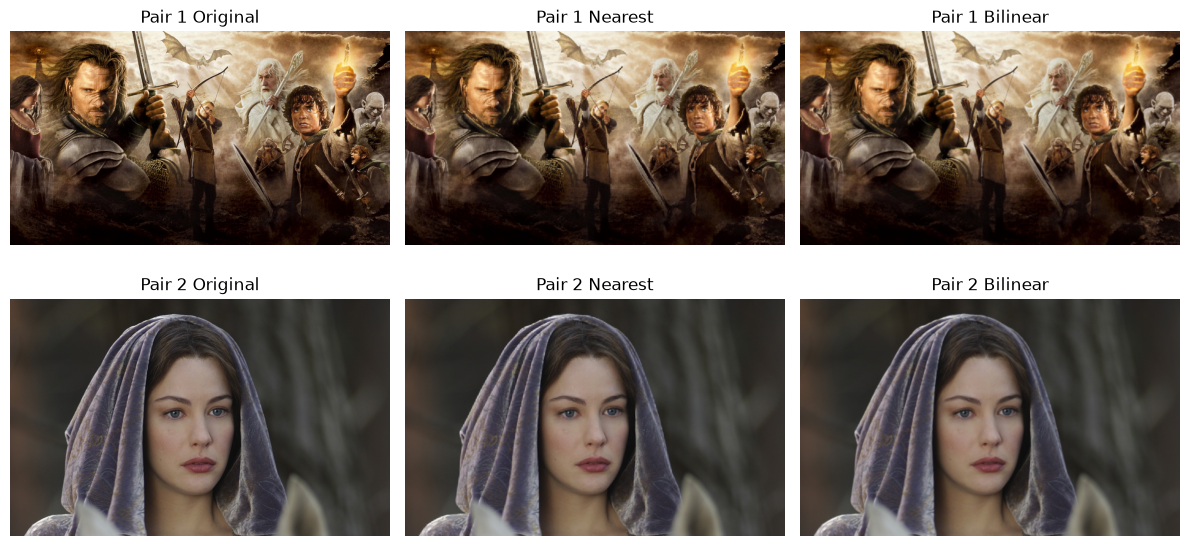

In [10]:
original1 = cv.imread("images/im01.png")
small1 = cv.imread("images/im01small.png")
original2 = cv.imread("images/im02.png")
small2 = cv.imread("images/im02small.png")

scale = 4
pair1_nn = zoom_image(small1, scale, method="nearest")
pair1_bilinear = zoom_image(small1, scale, method="bilinear")
pair2_nn = zoom_image(small2, scale, method="nearest")
pair2_bilinear = zoom_image(small2, scale, method="bilinear")

ssd_1_nn = normalized_ssd(original1, pair1_nn)
ssd_1_bilinear = normalized_ssd(original1, pair1_bilinear)
ssd_2_nn = normalized_ssd(original2, pair2_nn)
ssd_2_bilinear = normalized_ssd(original2, pair2_bilinear)

print(f"Pair 1 - Nearest Neighbor NSSD: {ssd_1_nn:.4f}")
print(f"Pair 1 - Bilinear NSSD:         {ssd_1_bilinear:.4f}")
print(f"Pair 2 - Nearest Neighbor NSSD: {ssd_2_nn:.4f}")
print(f"Pair 2 - Bilinear NSSD:         {ssd_2_bilinear:.4f}")

display_items = [
    (original1, "Pair 1 Original"), (pair1_nn, "Pair 1 Nearest"), (pair1_bilinear, "Pair 1 Bilinear"),
    (original2, "Pair 2 Original"), (pair2_nn, "Pair 2 Nearest"), (pair2_bilinear, "Pair 2 Bilinear")
]

plt.figure(figsize=(12, 6))
for i, (image, title) in enumerate(display_items, start=1):
    plt.subplot(2, 3, i)
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

Nearest-neighbor interpolation copies the closest source pixel and can produce blocky artifacts. Bilinear interpolation estimates each new value from neighboring pixels and generally gives smoother reconstructions. The normalized SSD values compare each zoomed result with the corresponding original image.

## Question 09 - Foreground Segmentation and Background Blur

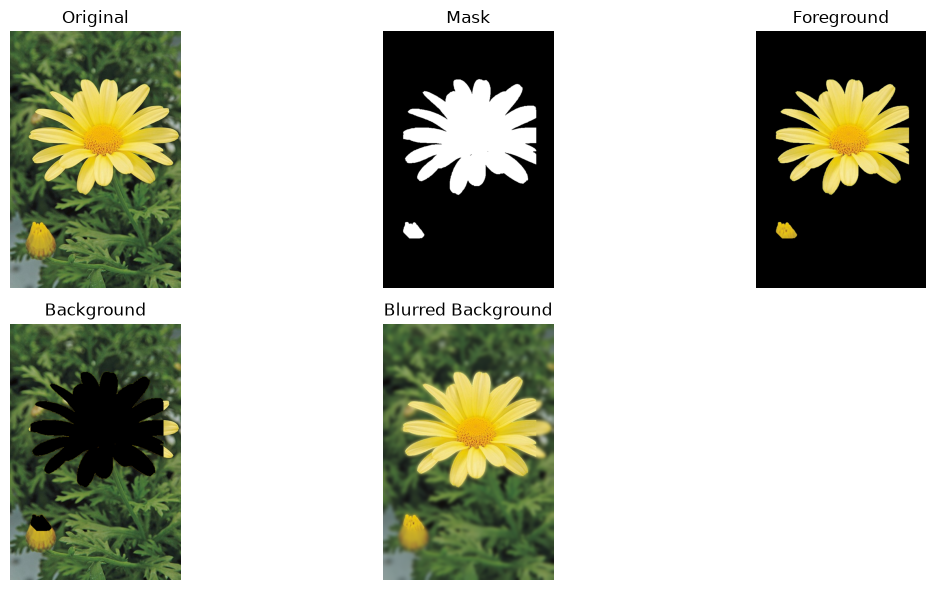

In [11]:
img = cv.imread("images/q8.jpeg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
h, w = img.shape[:2]

mask = np.zeros((h, w), np.uint8)
bg_model = np.zeros((1, 65), np.float64)
fg_model = np.zeros((1, 65), np.float64)
rect = (int(0.12 * w), int(0.08 * h), int(0.78 * w), int(0.75 * h))

cv.grabCut(img, mask, rect, bg_model, fg_model, 5, cv.GC_INIT_WITH_RECT)
binary_mask = np.where((mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD), 1, 0).astype(np.uint8)

foreground = img * binary_mask[:, :, np.newaxis]
background_mask = 1 - binary_mask
background = img * background_mask[:, :, np.newaxis]
blurred = cv.GaussianBlur(img, (31, 31), 0)
enhanced = foreground + blurred * background_mask[:, :, np.newaxis]

plt.figure(figsize=(12, 6))
for i, (image, title, cmap) in enumerate([
    (img_rgb, "Original", None),
    (binary_mask, "Mask", "gray"),
    (cv.cvtColor(foreground, cv.COLOR_BGR2RGB), "Foreground", None),
    (cv.cvtColor(background, cv.COLOR_BGR2RGB), "Background", None),
    (cv.cvtColor(enhanced, cv.COLOR_BGR2RGB), "Blurred Background", None)
], start=1):
    plt.subplot(2, 3, i)
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

GrabCut separates the flower from the background using the rectangle initialization. The foreground is preserved sharply while the background is replaced with a Gaussian-blurred version. Dark edges can appear near the flower boundary because blur and mask recombination mix foreground and background intensities around uncertain boundary pixels.

## Question 10 - Bilateral Filtering

MSE between Manual and OpenCV Bilateral: 8.1990


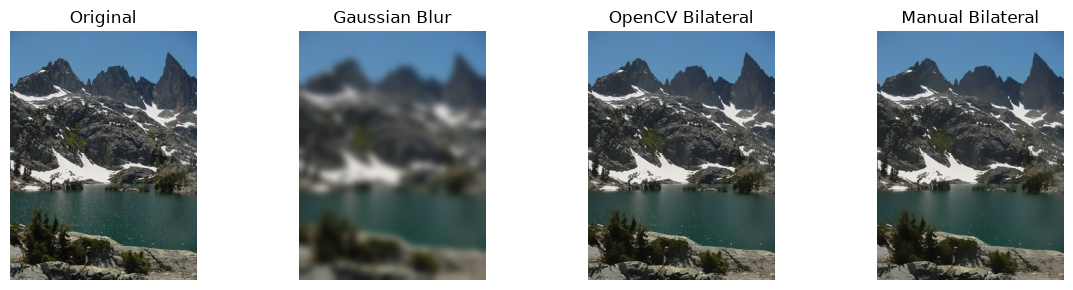

In [12]:
def bilateral_filter_manual(img, sigma_s, sigma_r, radius):
    h, w, c = img.shape
    padded = cv.copyMakeBorder(img, radius, radius, radius, radius, cv.BORDER_REFLECT).astype(np.float32)
    output = np.zeros_like(img, dtype=np.float32)
    y, x = np.mgrid[-radius:radius + 1, -radius:radius + 1]
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))
    img_float = img.astype(np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i + 2 * radius + 1, j:j + 2 * radius + 1]
            diff = region - img_float[i, j]
            color_distance_sq = np.sum(diff**2, axis=2)
            range_weights = np.exp(-color_distance_sq / (2 * sigma_r**2))
            weights = spatial_weights * range_weights
            output[i, j] = np.sum(region * weights[:, :, None], axis=(0, 1)) / np.sum(weights)

    return np.clip(output, 0, 255).astype(np.uint8)


img = cv.imread("images/q9.jpeg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

sigma_s = 5
sigma_r = 30
radius = int(3 * sigma_s)
kernel_size = 2 * radius + 1

gaussian = cv.GaussianBlur(img, (kernel_size, kernel_size), sigmaX=sigma_s)
bilateral_cv = cv.bilateralFilter(img, d=kernel_size, sigmaColor=sigma_r, sigmaSpace=sigma_s)
bilateral_manual = bilateral_filter_manual(img, sigma_s=sigma_s, sigma_r=sigma_r, radius=radius)
mse_manual_vs_cv = mse(bilateral_manual, bilateral_cv)

print(f"MSE between Manual and OpenCV Bilateral: {mse_manual_vs_cv:.4f}")

plt.figure(figsize=(12, 3))
for i, (image, title) in enumerate([
    (img_rgb, "Original"),
    (cv.cvtColor(gaussian, cv.COLOR_BGR2RGB), "Gaussian Blur"),
    (cv.cvtColor(bilateral_cv, cv.COLOR_BGR2RGB), "OpenCV Bilateral"),
    (cv.cvtColor(bilateral_manual, cv.COLOR_BGR2RGB), "Manual Bilateral")
], start=1):
    plt.subplot(1, 4, i)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

Gaussian filtering smooths based only on spatial distance, so it also blurs edges. Bilateral filtering combines spatial distance with intensity similarity, smoothing within regions while preserving edges. The low MSE between the manual and OpenCV bilateral outputs indicates that the manual implementation closely matches OpenCV's result.